In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [3]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
geolocation = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")
category_translation = pd.read_csv("../data/raw/product_category_name_translation.csv")

In [4]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "products": products,
    "reviews": reviews,
    "sellers": sellers,
    "geolocation": geolocation,
    "category_translation": category_translation
}

In [5]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


In [6]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

orders[date_columns] = orders[date_columns].apply(pd.to_datetime)

<Axes: xlabel='order_status'>

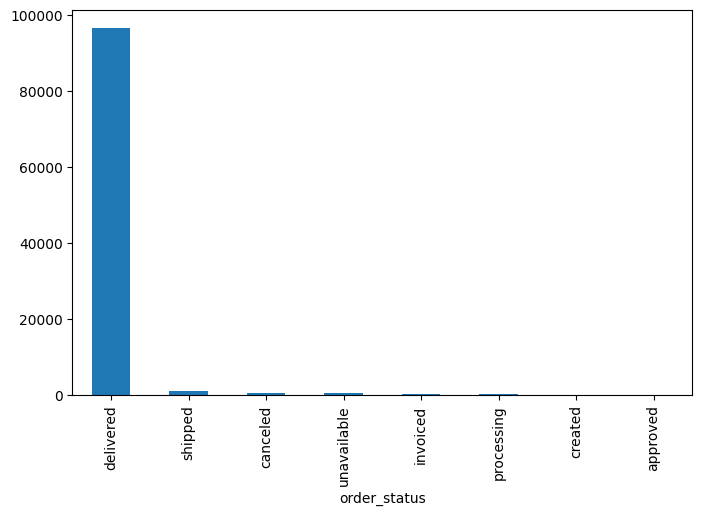

In [ ]:
orders["order_status"].value_counts().plot.bar(figsize=(8,5))


## We observe 
### 1. most of the orders are delivered
### 2. cancellations are rare

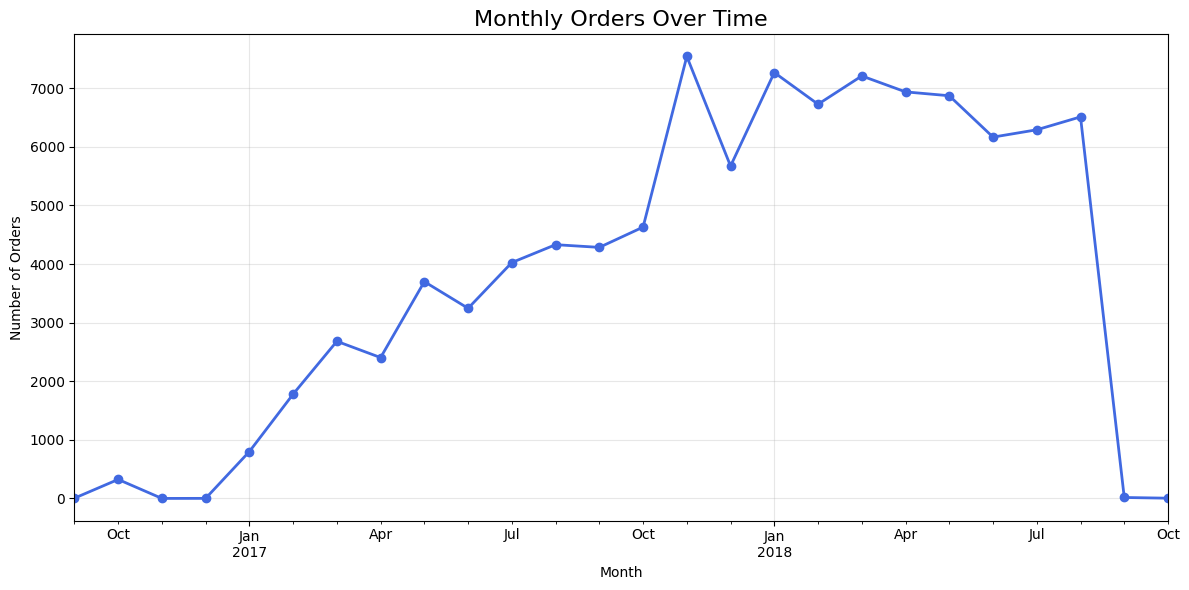

In [11]:
monthly_orders = (
    orders
    .set_index("order_purchase_timestamp")
    .resample("ME")
    .size()
)
plt.figure(figsize=(12, 6))

monthly_orders.plot(
    marker='o',
    linewidth=2,
    color='royalblue'
)

plt.title("Monthly Orders Over Time", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.grid(alpha=0.3)

plt.tight_layout()


In [14]:
customers["customer_unique_id"].nunique()

96096

In [13]:
customers["customer_id"].nunique()

99441

In [ ]:
customer_orders = (
    orders
    .merge(customers, on="customer_id")
    .groupby('customer_unique_id')
    .agg(total_orders=('order_id', 'nunique'))
    .reset_index()
)
customer_orders.head(10)

,customer_unique_id,total_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1
...,...,...
96081,fff3a9369e4b7102fab406a334a678c3,1
96082,fff3e1d7bc75f11dc7670619b2e61840,1
96083,fff5eb4918b2bf4b2da476788d42051c,1
96084,fff699c184bcc967d62fa2c6171765f7,1


In [ ]:
order_counts = customer_orders['total_orders'].value_counts().sort_index()


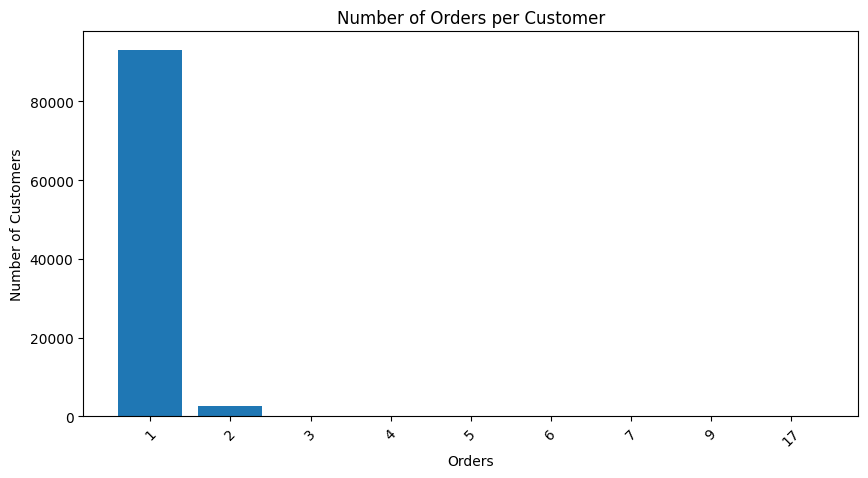

In [20]:
plt.figure(figsize=(10,5))
plt.bar(order_counts.index.astype(str), order_counts.values)
plt.title("Number of Orders per Customer")
plt.xlabel("Orders")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

#### Most customers placed only one order, while a much smaller proportion made repeat purchases. The customer base is therefore heavily skewed toward one-time buyers.

In [32]:
order_counts

total_orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [33]:
revenue = (
    orders.merge(payments, on="order_id")
)

In [34]:
monthly_revenue = (
    revenue
    .set_index("order_purchase_timestamp")
    .resample("ME")["payment_value"]
    .sum()
)

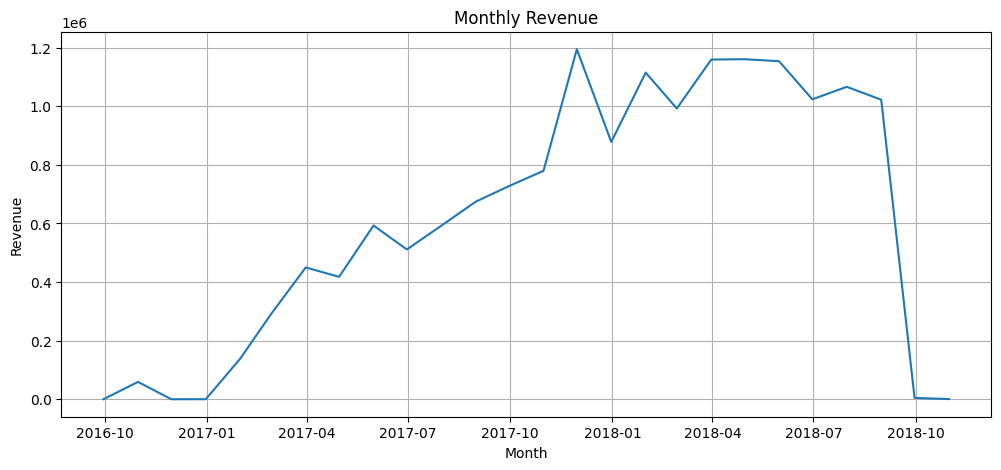

In [35]:
plt.figure(figsize=(12,5))
plt.plot(monthly_revenue)
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

##### Revenue increased from beginning of 2017 peaked during seasons and holidays, suggesting promotional periods or holiday shopping.

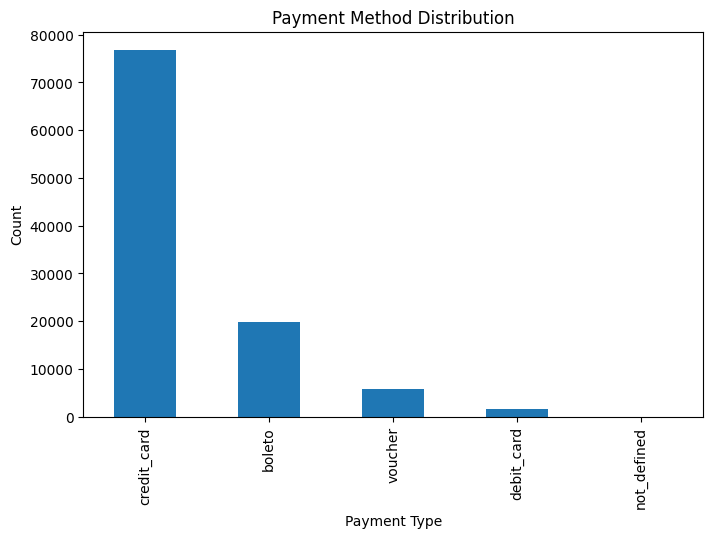

In [36]:
payment_counts = (
    payments["payment_type"]
    .value_counts()
)
plt.figure(figsize=(8,5))
payment_counts.plot(kind="bar")
plt.title("Payment Method Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.show()

##### credit card payments insanely dominate debit_card payments 

Text(0, 0.5, 'Count')

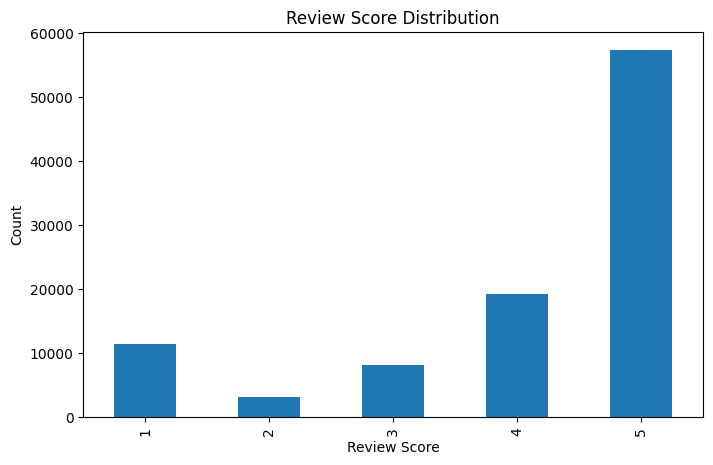

In [37]:
review_counts = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
)
plt.figure(figsize=(8,5))
review_counts.plot(kind='bar')
plt.title('Review Score Distribution')
plt.xlabel("Review Score")
plt.ylabel("Count")

##### Customers mostly review 5 star ratings, indicating higher customer satisfaction. There are still 1 star ratings suggesting poor customer experiences to be improved.

In [39]:
product_sales = (
    order_items.merge(products, on= 'product_id')
    .merge(category_translation, on='product_category_name')
)
top_categories = (
    product_sales['product_category_name_english']
    .value_counts()
    .head(10)
)

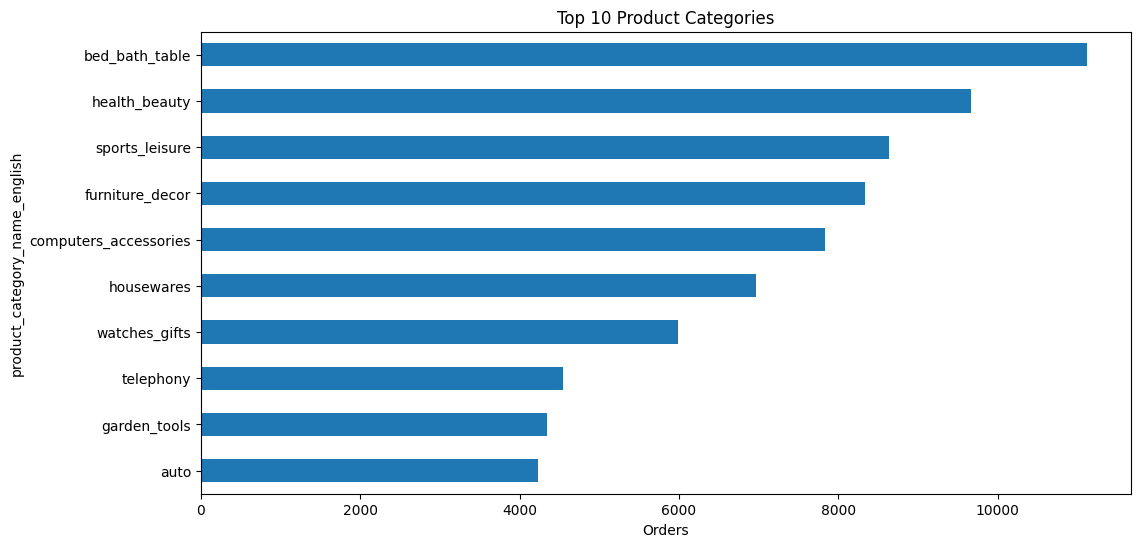

In [40]:
plt.figure(figsize=(12,6))
top_categories.sort_values().plot(kind="barh")
plt.title("Top 10 Product Categories")
plt.xlabel("Orders")
plt.show()

Text(0.5, 1.0, 'Top 10 Product Categories')

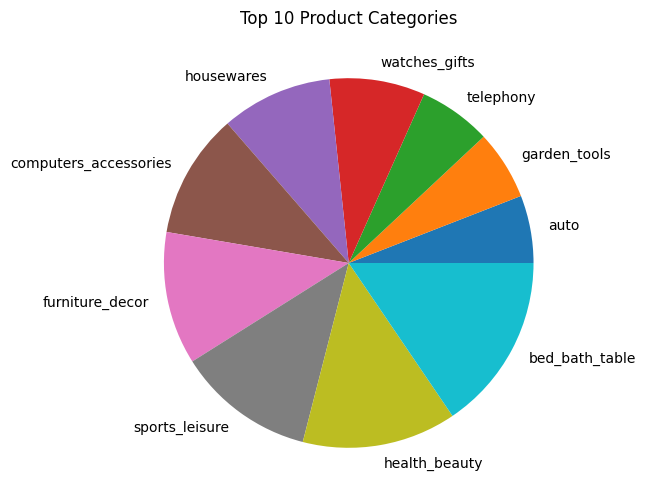

In [42]:
plt.figure(figsize=(12,6))
top_categories.sort_values().plot(kind="pie")
plt.title("Top 10 Product Categories")

##### Customers prefer Bed, bath, and table products with the highest sales, followed by health & beauty and sports & leisure products.

### CLV Relevance
- Repeat purchase behavior indicates that customers with multiple historical orders are likely to generate higher future revenue, making purchase frequency an important predictive feature.
- Revenue trends over time highlight seasonal variations and business growth patterns, suggesting that time-based features such as purchase month, customer tenure, and recency may improve model performance.
- Payment method preferences reveal differences in customer purchasing behavior. Features such as preferred payment type and installment usage may help distinguish spending patterns across customers.
- Customer review scores serve as a proxy for customer satisfaction. Higher satisfaction may increase the likelihood of repeat purchases, while poor reviews could indicate a higher risk of customer churn.
- Product category preferences provide insights into customer interests and purchasing diversity. Customers who buy across multiple categories may exhibit stronger engagement and higher lifetime value.